## Optimization of   first-generation antihistamines to design imroved (second-generation) agents.

### In this example we will attempt to optimize 1st generation antihistamine drugs: used in the past to manage allergies. The aim of optimization  is to reduce side effects: sleepiness, drowsiness, decreased attention; while keeping high anti-allergy activity. Modern antihistamines, e.g. cetirizine, loratadine etc. don't display these  side effects. This is thanks to lower blood-brain-barrier peneteration and higher receptor selectivity.
### Our aim  can be  achieved by simultaneously reducing blood-brain-barrier permeability  and keeping high *H1* histamine receptor activity. So, we will perform two-parameter optimization. (We will not optimize receptor selectivity in this example, as we would like to limit the number of parameters to two for simplicity.)

In [1]:
import os
from copy import copy
from optimizer import optimize
import process_config
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import pandas as pd
import sqlite3
import gzip, shutil
import platform

# Download the database for fragment replacements form DropBox.
## Note, download it to examples/ folder, because this is where the program will expect it to be, as specified in settings below:

In [2]:
dropbox_url = "https://www.dropbox.com/s/4r48ohopechsd59/replacements02_sa2.db.gz?dl=1"
output_filename = "examples/replacements02_sa2.db.gz"  
extracted_filename = "examples/replacements02_sa2.db" 


is_windows = platform.system() == "Windows"

if is_windows:

    download_cmd = f'curl -L "{dropbox_url}" -o {output_filename}'
    extract_cmd = f'gunzip -kf {output_filename}'
    !{download_cmd}
    !{extract_cmd}
else:
    # Linux/macOS 
    from IPython.display import display, Markdown

    bash_script = f"""
    set -e
    curl -L "{dropbox_url}" -o {output_filename}
    gzip -dk {output_filename}
    """
    with open("temp_script.sh", "w") as f:
        f.write(bash_script)
    !bash temp_script.sh
    os.remove("temp_script.sh")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   141  100   141    0     0    541      0 --:--:-- --:--:-- --:--:--   542
100    17  100    17    0     0     24      0 --:--:-- --:--:-- --:--:--    24
100   475    0   475    0     0    292      0 --:--:--  0:00:01 --:--:--     0
100  380M  100  380M    0     0  18.7M      0  0:00:20  0:00:20 --:--:-- 20.2M  13 49.6M    0     0  11.8M      0  0:00:32  0:00:04  0:00:28 26.1M77  296M    0     0  18.3M      0  0:00:20  0:00:16  0:00:04 20.2M
gzip: examples/replacements02_sa2.db already exists; do you wish to overwrite (y or n)? ^C


## 1. Let's read input settings from configuration file, which we prepared in advance


In [2]:
input_config = "examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/input_config.yaml"

In [3]:
settings = process_config.test_config(input_config)

In [4]:
settings

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 0.0,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounding_box': True,
 'smarts_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'replacement_database': 'examples/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'num_of_generations': 3,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,
  'desirability': '6:0,10:0.25*x-1.5,100:1'},
 'param_1': {'name': 'logbb',
  'path': 'examples

#### Some of  important settings are:
##### num_output_compounds: number of compounds with desired properties to be generated. The program will stop once this is satisfied (unless it will stop earlier upon satisfying another condition). 
##### number_of_selected_compounds: number of compounds selected for optimization in one generation. 
##### Larger  number will lead to: (1) more compounds in the final database of generated compounds (including both: optimal and non-optimal compounds); (2) longer overall running time; (3) lower  selection pressure at each generation. Smaller number will lead to opposite: (1) less compounds will be generated; (2) faster results; (3) selection pressure   at each generation  will be higher.
##### num_of_generations: maximum number of generations. Program will stop, once this is satisfied (unless stopped earlier upon another condition).
##### optimization_method: optimization method to use, i.e. desirability, or pareto (not both). 
##### protected_ids: field name in sdf file (with structure(s) to be optimized), which contains 0-based ids of atoms, that should not be affected by optimization. For instance, this could be an active scaffold which you  wish to retain.
#### For full description of all the settings, please, refer to README of the Crem_ml project.

In [5]:
# lets make a copy of settings dict to look at it later (optimizer will change some values in the original dict)
settings_copy = copy(settings)

### 2.  Let's look at our starting molecule to be optimized. This is a first generation antihistamine agent: decloxizine.  


In [6]:
sdf = Chem.SDMolSupplier(settings["seed_structure"])

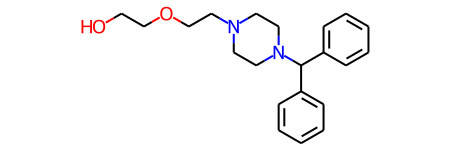

In [7]:
sdf[0]

## 3. Now, we can perform seed compound optimization

#### We will use settings, which we  have read from the config file. 


In [8]:
try:  # handling of sys.exit() in python code to run smoothly all cells
    optimize(settings=settings,
                   input_config=input_config,
                   brute_force=False)
except SystemExit as e:
    pass
    


__________________________________________________ 
Generation 0: 2025-06-21 11:55:33.593368
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
Processing predictions ...
Finding fragments has started
[<rdkit.Chem.rdchem.Mol object at 0x7f7348b34030>, <rdkit.Chem.rdchem.Mol object at 0x7f7348b34348>]
c1ccc(C(c2ccccc2)N2CCN(CCOCC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7348b34c90>, <rdkit.Chem.rdchem.Mol object at 0x7f7348b34608>]
c1ccc(C(c2ccccc2)N2CCN(CCOC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7348b34348>, <rdkit.Chem.rdchem.Mol object at 0x7f7348b34500>]
c1ccc(C(c2ccccc2)N2CCN(CCO[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7348b34608>, <rdkit.Chem.rdchem.Mol object at 0x7f7348b34ad8>]
c1ccc(C(c2ccccc2)N2CCN(CC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7348b34500>, <rdkit.Chem.rdchem.Mol object at 0x7f7348b34138>]
c1ccc(C(c2ccccc2)N2CCN(C[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object a

/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Fragment contribution for logbb started
Processing contributions ...
Replacing fragments ...


RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:55:36] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:

__________________________________________________ 
Generation 1: 2025-06-21 11:55:40.507919
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
Processing predictions ...


...

RDKit WARNING: [11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:13] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:13] WARNING: not removing h

RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:56:20] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [11:56:21] WARNING:

__________________________________________________ 
Generation 2: 2025-06-21 11:56:42.900718
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
Processing predictions ...


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Optimizer reached number of fitted compounds specified in config.
[Notebook caught sys.exit] Reason: 


### 4. Now  we can look at results
### in working directory we have a folder with the optimizer output: *out* 

In [9]:
settings_copy['working_dir']

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN'

In [10]:
os.listdir(settings_copy['working_dir']+"/out")  # there are 3 generations, as we defined in settings

['generation_0', 'generation_1', 'generation_2']

In [33]:
os.listdir(settings_copy['working_dir'] + '/out//generation_2')  # let's look into the last generation

['input_dataset.sdf',
 'input_dataset_Hs.sdf',
 'output_match.sdf',
 'predictions_231.txt',
 'predictions_logbb.txt',
 'processed_predictions.sdf',
 'x.colnames',
 'x.rownames',
 'x.txt']

#### *output_match.sdf* is the file with compounds, having favorable  values of parameters (predicted).
#### Let' s look at them (in previous generations there might also be such compounds, but for now we will explore just last one)

In [37]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_2/output_match.sdf")

In [38]:
mols = []
for mol in sdf:
    mols.append(mol)

In [39]:
for m in mols:
    AllChem.Compute2DCoords(m)

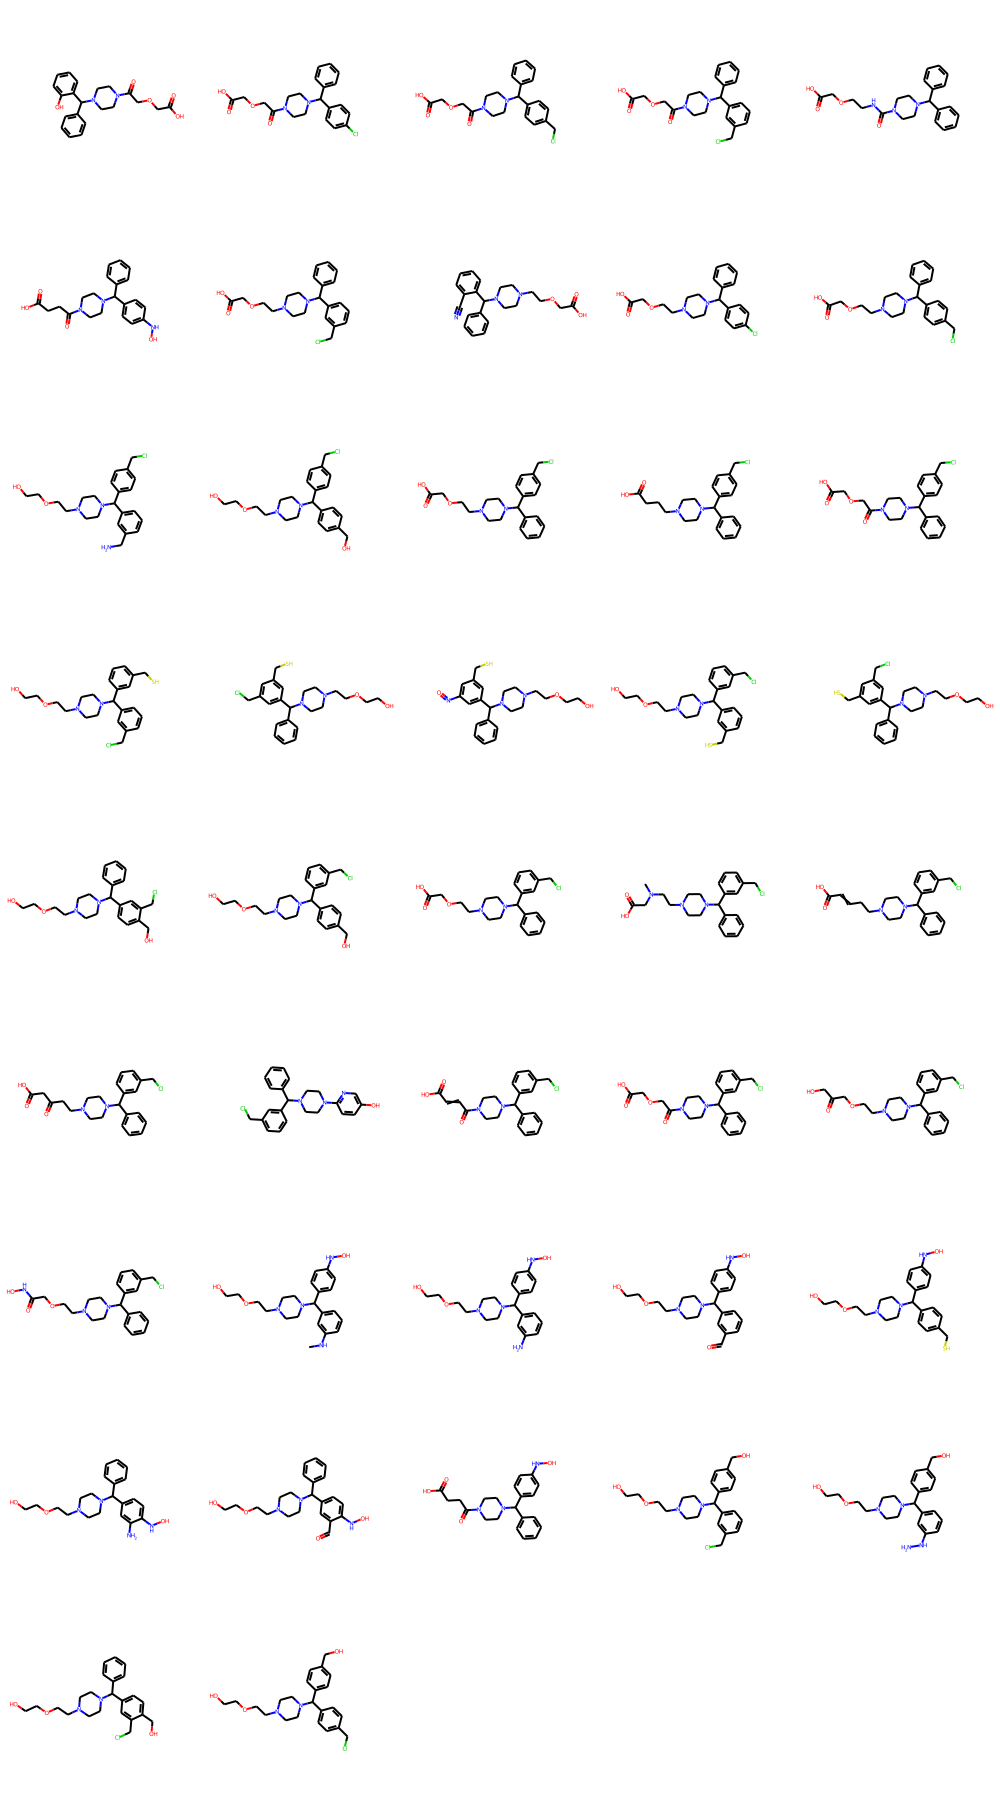

In [40]:
Draw.MolsToGridImage(mols, molsPerRow=5)

## We can recognize here a known antihistamine drug of 2nd generation in the results: cetirizine. 

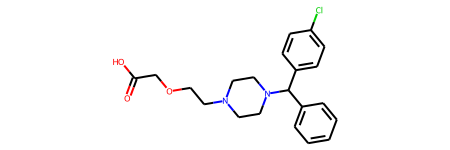

In [41]:
cetirizine = Chem.MolFromSmiles("OC(=O)COCCN1CCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1")
cetirizine

## Let's find it in our sdf file.  We can run similarity search based on ECFP  fingerprints (RDKIT)

In [42]:
cetirizine_ecfp = AllChem.GetMorganFingerprintAsBitVect(cetirizine ,radius=3)

In [43]:
for mol in mols:
    if  DataStructs.FingerprintSimilarity(AllChem.GetMorganFingerprintAsBitVect(mol,radius=3), cetirizine_ecfp) == 1:
        print(mol.GetPropsAsDict())

{'parent_name': 'ID_1_158', 'transformation': '[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[Cl]-[c:6](:[c:4]:[*:2]):[c:5]:[*:3]', 'protected_ids': '1,2,3,4,5,7,9,10,11,13,14,15,16,17,20,23,25,27,32', 'ID': 'ID_2_544', 'pred_231': ' 7.428', 'pred_logbb': ' 0.269'}



#### Lets compare predictions of our models and true activity data for this molecule, taken from the ChEMBL database. 
####  As we can see, predicted values for  'ID_2_5314'  (cetirizine) H1 affinity is 7.42 (log units), and logBB is 0.269 (probability to cross BBB). True H1 activity is 8.2 and true ability to pass through BBB is low (class 0).
#### The predicted values for all generated molecules are in the properties dict above. They also can be found in the database file *output.db*, as well as in the pedictions_XXX.txt files for every generation (XXX is the name of parameter as in config.yaml).

## 5.  Conclusion:
### We could design cetirizine - a known 2nd generation antihistamine drug in 3 generations. As we can see, predicted values of affinity and logBB  are close to experimental data. This is a successsful result.

## 6. Now, let's perform the same task, but this time we will use *random compound selection*, to illustrate that the use of QSAR models in optimization really guides it to favorable compounds, while random selection may not work. 
### (Note, we will try fully random selection; however, in the case of partial randomness we  can get good results, see README.md)
 
#### We will use settings, which we  have read from the config file, but change "random_compound_selection" to 100%

In [13]:
settings_copy['random_compounds_selection'] = 1
# also, it's recommended to correct this value manually in the config.yaml after it is  saved by the program to working dir (for keeping track of experiments)

In [14]:
# let's  write results to a different folder
os.mkdir(settings_copy['working_dir'] + "_random_compounds")
settings_copy['working_dir'] = settings_copy['working_dir'] + "_random_compounds"
settings_copy['working_dir'] 

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds'

In [15]:
settings_copy

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 1,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounding_box': True,
 'smarts_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'replacement_database': 'examples/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'num_of_generations': 3,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,
  'desirability': '6:0,10:0.25*x-1.5,100:1'},
 'param_1': {'name': 'logbb',
  'p

In [ ]:
try: # handling of sys.exit() in python code to run smoothly all cells
    optimize(settings=settings_copy,
                   input_config=input_config,
                   brute_force=False)  
except SystemExit as e:
    pass

__________________________________________________ 
Generation 0: 2025-06-21 12:04:23.847915
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
Processing predictions ...
Finding fragments has started
[<rdkit.Chem.rdchem.Mol object at 0x7f7398553a80>, <rdkit.Chem.rdchem.Mol object at 0x7f7398553978>]
c1ccc(C(c2ccccc2)N2CCN(CCOCC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398553c38>, <rdkit.Chem.rdchem.Mol object at 0x7f7398553920>]
c1ccc(C(c2ccccc2)N2CCN(CCOC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398553978>, <rdkit.Chem.rdchem.Mol object at 0x7f7398553df0>]
c1ccc(C(c2ccccc2)N2CCN(CCO[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398553920>, <rdkit.Chem.rdchem.Mol object at 0x7f7398553d40>]
c1ccc(C(c2ccccc2)N2CCN(CC[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398553df0>, <rdkit.Chem.rdchem.Mol object at 0x7f73985535b0>]
c1ccc(C(c2ccccc2)N2CCN(C[*])CC2)cc1
[<rdkit.Chem.rdchem.Mol object a

/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Fragment contribution for logbb started
Processing contributions ...
Replacing fragments ...


RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:08:11] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [12:

__________________________________________________ 
Generation 1: 2025-06-21 12:08:15.820305
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
Processing predictions ...


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Finding fragments has started
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766ce8>, <rdkit.Chem.rdchem.Mol object at 0x7f73987661e8>]
OCCOCCN1CCN(C(c2ccccc2)c2ccc([*])cc2)CC1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766660>, <rdkit.Chem.rdchem.Mol object at 0x7f73987663a0>]
OCCOCCN1CCN(C(c2ccccc2)[*])CC1
[<rdkit.Chem.rdchem.Mol object at 0x7f73987661e8>, <rdkit.Chem.rdchem.Mol object at 0x7f7398766ce8>]
OCCOCCN1CCN([*])CC1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766660>, <rdkit.Chem.rdchem.Mol object at 0x7f73987663a0>]
c1ccc([*])cc1
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766ce8>, <rdkit.Chem.rdchem.Mol object at 0x7f7398766f50>]
OCCOCC[*]
[<rdkit.Chem.rdchem.Mol object at 0x7f73987663a0>, <rdkit.Chem.rdchem.Mol object at 0x7f7398766ea0>]
OCCOC[*]
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766f50>, <rdkit.Chem.rdchem.Mol object at 0x7f7398766348>]
OCCO[*]
[<rdkit.Chem.rdchem.Mol object at 0x7f7398766ea0>, <rdkit.Chem.rdchem.Mol object at 0x7f7398766ad8>]
OCC[*]
[<rdkit.Chem.rdchem.Mo

Fragment contribution for 231 started
Fragment contribution for logbb started
Processing contributions ...
Replacing fragments ...


In [ ]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//out/generation_2/output_match.sdf")
mols = []
for mol in sdf:
    mols.append(mol)
for m in mols:
    AllChem.Compute2DCoords(m)

In [ ]:
Draw.MolsToGridImage(mols, molsPerRow=5)

### It looks like we don't have cetirizine among the results. However, let's check the whole generated database. Main table of the database is called optimizer_table, and we will use sqlite python module to connect to it

In [ ]:
con = sqlite3.connect("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//output.db")

In [ ]:
sql_query = """SELECT * FROM optimizer_table"""

In [ ]:
df = pd.read_sql_query(sql_query,con)

In [ ]:
df

In [ ]:
# to quickly find cetirizine in this table, we can run similarity search based on ECFP  fingerprints from RDKIT

In [ ]:
df["ecfp"] = df.smi.apply(lambda x: AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), radius=3))

In [ ]:
df["ecfp_sim"] = df.ecfp.apply(lambda x: DataStructs.FingerprintSimilarity(x, cetirizine_ecfp))

### Let's sort our table from the most to the least similar to cetirizine.

In [ ]:
df.sort_values("ecfp_sim", ascending=False)

### There's no compound with 100% similarity to cetirizine, so  there is no cetirizine. This means it was helpful to perform QSAR guided compound selection versus random. 